In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import time
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris, make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score





### zad 1

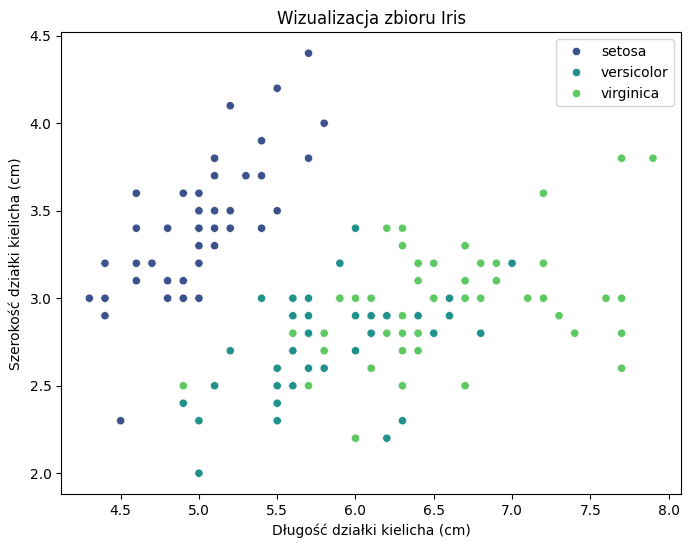

In [10]:
iris = load_iris()
X = iris.data 
y = iris.target 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=iris.target_names[y], palette='viridis')
plt.xlabel('Długość działki kielicha (cm)')
plt.ylabel('Szerokość działki kielicha (cm)')
plt.title('Wizualizacja zbioru Iris')
plt.legend()
plt.show()

In [11]:
clf = DecisionTreeClassifier(
    max_depth=3, 
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Dokładność modelu: {accuracy:.2f}')

Dokładność modelu: 1.00


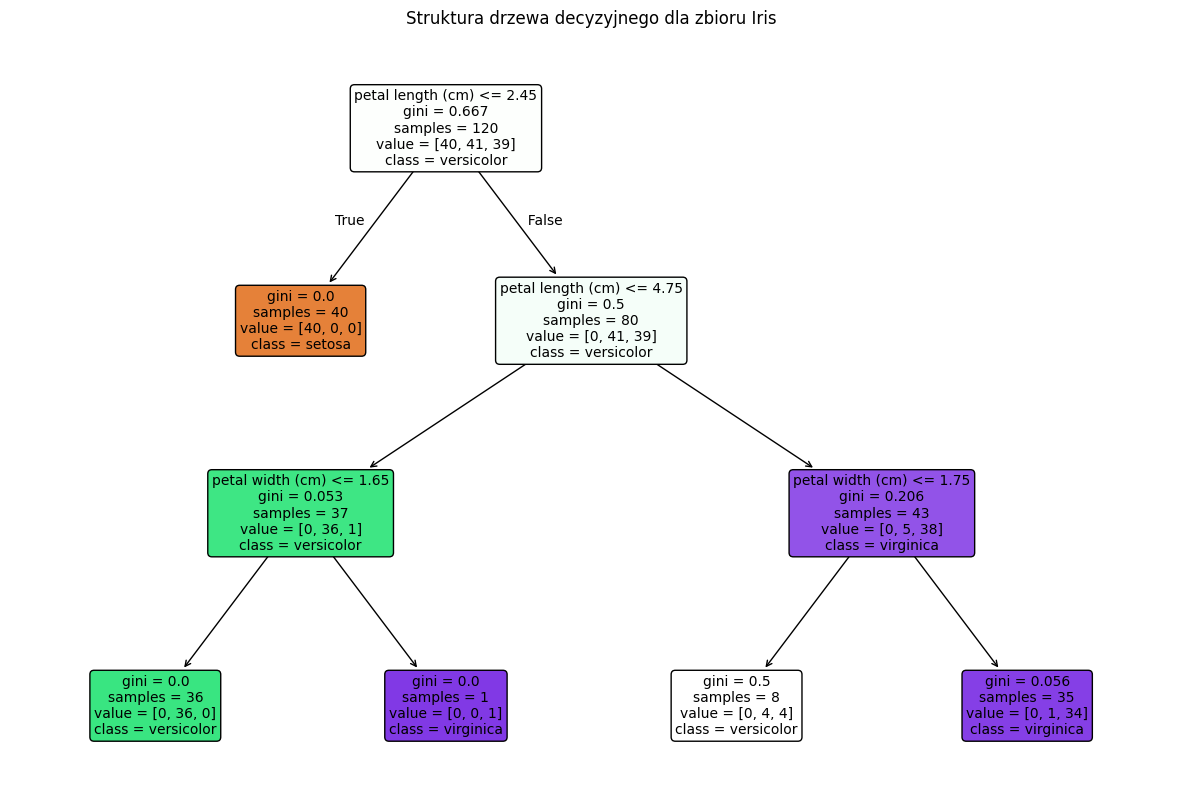

In [12]:
plt.figure(figsize=(15, 10))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Struktura drzewa decyzyjnego dla zbioru Iris')
plt.show()

### zad 2

Drzewo bez ograniczeń:
  Dokładność treningowa: 1.0000 (100.00%)
  Dokładność testowa:    1.0000 (100.00%)
  Różnica: 0.0000

Drzewo z ograniczeniami (max_depth=3):
  Dokładność treningowa: 0.9524 (95.24%)
  Dokładność testowa:    1.0000 (100.00%)
  Różnica: -0.0476


<Figure size 2000x1000 with 0 Axes>

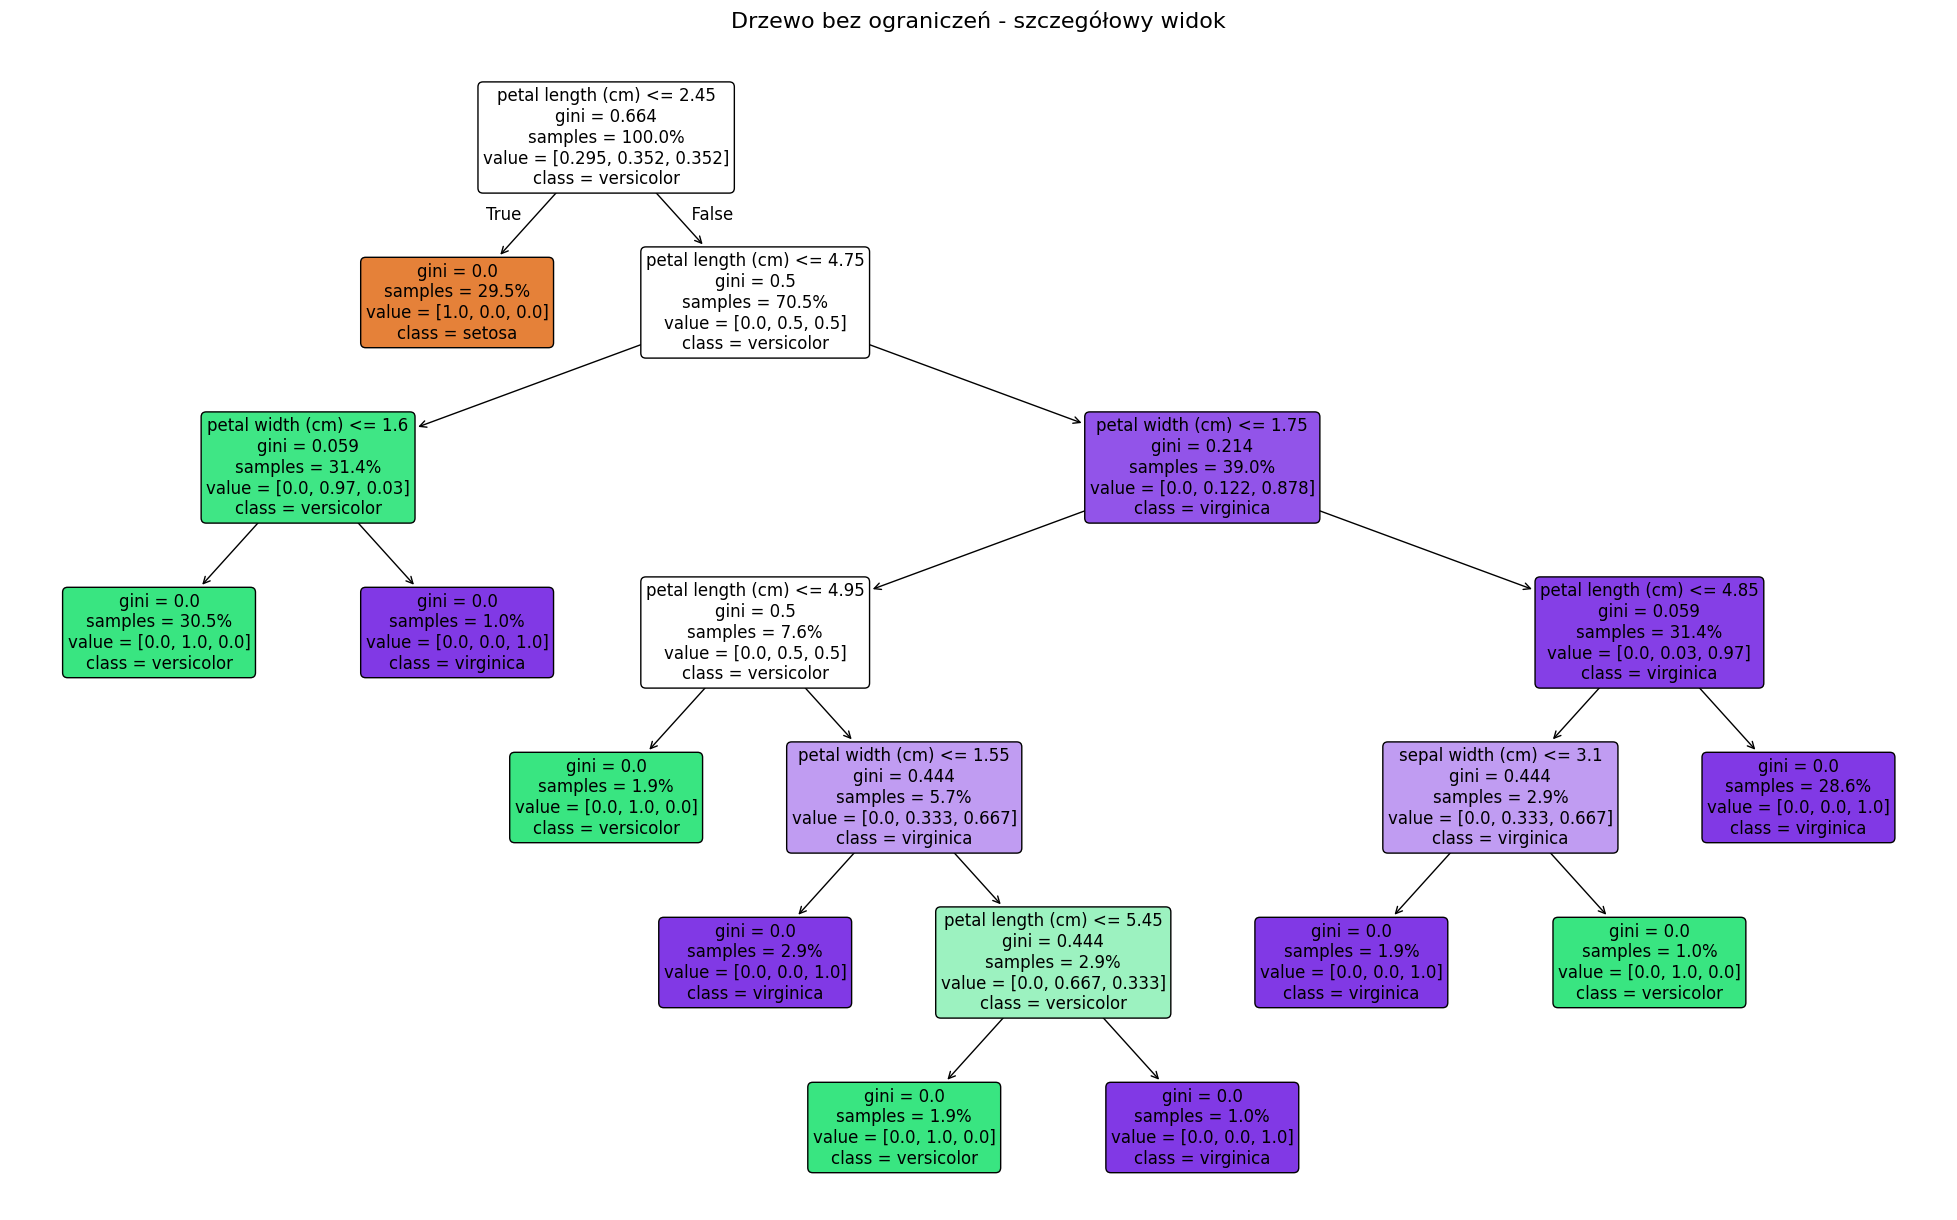

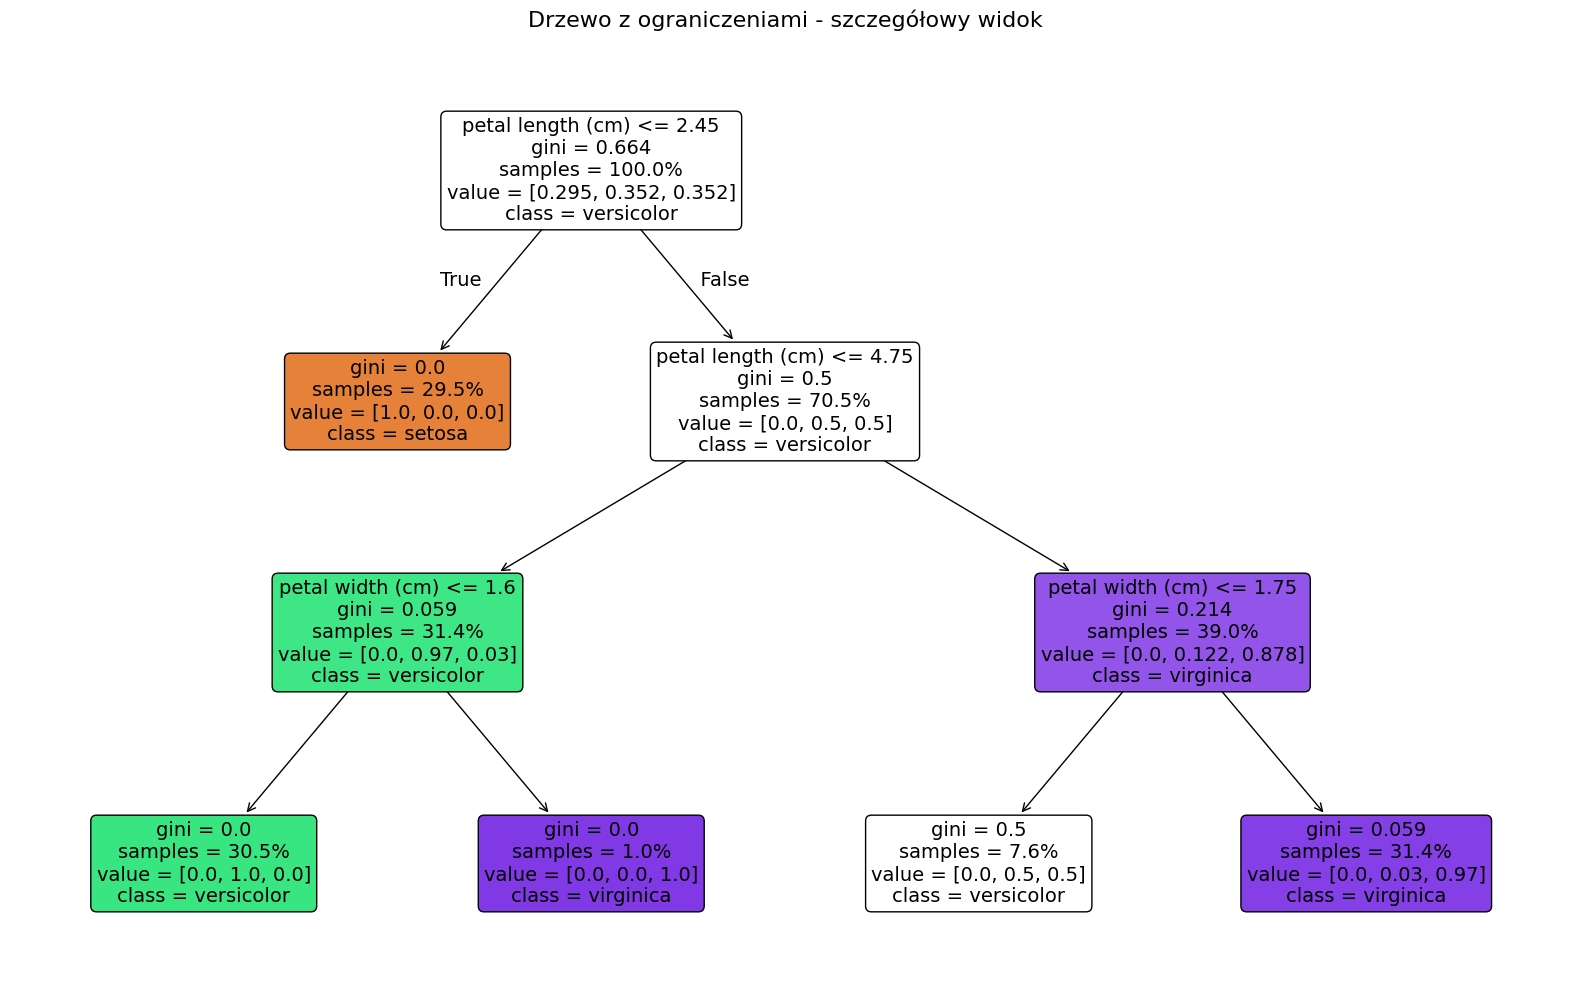

In [13]:
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

tree_unlimited = DecisionTreeClassifier(random_state=42)
tree_unlimited.fit(X_train, y_train)

tree_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_limited.fit(X_train, y_train)

train_acc_unlimited = tree_unlimited.score(X_train, y_train)
test_acc_unlimited = tree_unlimited.score(X_test, y_test)

train_acc_limited = tree_limited.score(X_train, y_train)
test_acc_limited = tree_limited.score(X_test, y_test)

print(f"Drzewo bez ograniczeń:")
print(f"  Dokładność treningowa: {train_acc_unlimited:.4f} ({train_acc_unlimited*100:.2f}%)")
print(f"  Dokładność testowa:    {test_acc_unlimited:.4f} ({test_acc_unlimited*100:.2f}%)")
print(f"  Różnica: {train_acc_unlimited - test_acc_unlimited:.4f}")

print(f"\nDrzewo z ograniczeniami (max_depth=3):")
print(f"  Dokładność treningowa: {train_acc_limited:.4f} ({train_acc_limited*100:.2f}%)")
print(f"  Dokładność testowa:    {test_acc_limited:.4f} ({test_acc_limited*100:.2f}%)")
print(f"  Różnica: {train_acc_limited - test_acc_limited:.4f}")

plt.figure(figsize=(20, 10))


plt.figure(figsize=(25, 15))
plot_tree(tree_unlimited, feature_names=iris.feature_names, 
          class_names=iris.target_names, filled=True, rounded=True,
          fontsize=12, impurity=True, proportion=True)
plt.title('Drzewo bez ograniczeń - szczegółowy widok', fontsize=16, pad=20)
plt.show()

plt.figure(figsize=(20, 12))
plot_tree(tree_limited, feature_names=iris.feature_names, 
          class_names=iris.target_names, filled=True, rounded=True,
          fontsize=14, impurity=True, proportion=True)
plt.title('Drzewo z ograniczeniami - szczegółowy widok', fontsize=16, pad=20)
plt.show()


### zad 3

In [14]:
X, y = make_classification(n_samples=1000, n_features=20, random_state=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

dt_scores = cross_val_score(dt, X_train, y_train, cv=5)
rf_scores = cross_val_score(rf, X_train, y_train, cv=5)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Porównanie modeli:")
print(f"Drzewo - Dokładność CV: {dt_scores.mean():.4f} (±{dt_scores.std():.4f})")
print(f"Drzewo - Dokładność test: {dt.score(X_test, y_test):.4f}")
print(f"Las     - Dokładność CV: {rf_scores.mean():.4f} (±{rf_scores.std():.4f})")
print(f"Las     - Dokładność test: {rf.score(X_test, y_test):.4f}")

Porównanie modeli:
Drzewo - Dokładność CV: 0.8714 (±0.0169)
Drzewo - Dokładność test: 0.8633
Las     - Dokładność CV: 0.9229 (±0.0236)
Las     - Dokładność test: 0.8833


### zadanie 4

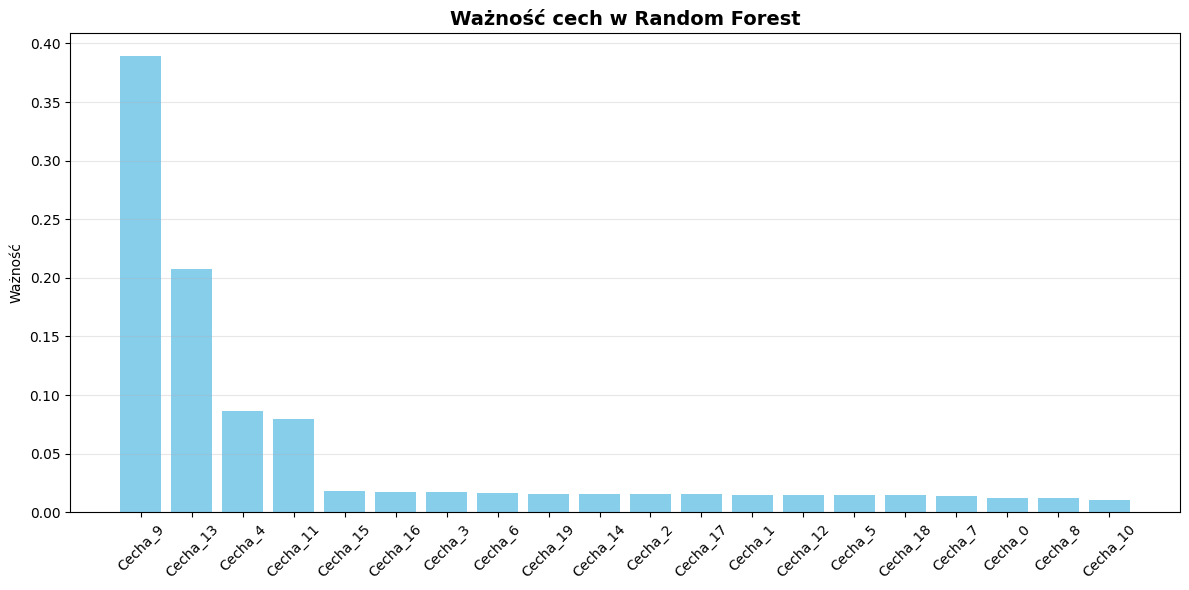

Interpretacja ważności cech:
Najważniejsze cechy: Cecha_9 (0.3892)
Drugą najważniejsza: Cecha_13 (0.2077)
Trzecia najważniejsza: Cecha_4 (0.0862)

Liczba mało ważnych cech (ważność < 0.01): 0


In [15]:
importance = rf.feature_importances_
features = [f'Cecha_{i}' for i in range(X.shape[1])]

df_importance = pd.DataFrame({'cecha': features, 'ważność': importance})
df_importance = df_importance.sort_values('ważność', ascending=False)


plt.figure(figsize=(12, 6))
plt.bar(df_importance['cecha'], df_importance['ważność'], color='skyblue')
plt.title('Ważność cech w Random Forest', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Ważność')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


print("Interpretacja ważności cech:")
print(f"Najważniejsze cechy: {df_importance['cecha'].iloc[0]} ({df_importance['ważność'].iloc[0]:.4f})")
print(f"Drugą najważniejsza: {df_importance['cecha'].iloc[1]} ({df_importance['ważność'].iloc[1]:.4f})")
print(f"Trzecia najważniejsza: {df_importance['cecha'].iloc[2]} ({df_importance['ważność'].iloc[2]:.4f})")
print(f"\nLiczba mało ważnych cech (ważność < 0.01): {len(df_importance[df_importance['ważność'] < 0.01])}")

### zadanie 5

n_estimators:   1 | Train: 0.9100 | Test: 0.8833
n_estimators:  10 | Train: 0.9100 | Test: 0.8833
n_estimators:  50 | Train: 0.9429 | Test: 0.8733
n_estimators: 100 | Train: 0.9614 | Test: 0.8667
n_estimators: 200 | Train: 0.9857 | Test: 0.8600


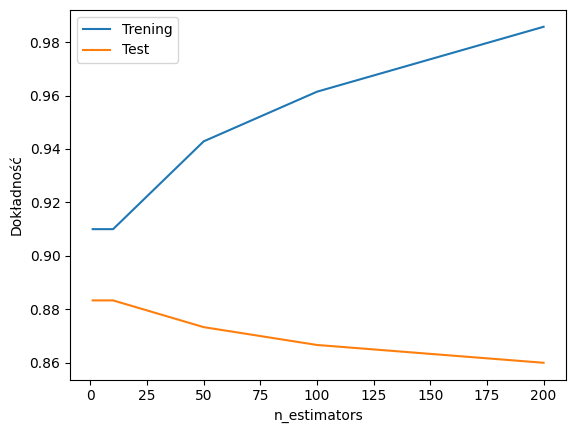

In [16]:
n_estimators_range = [1, 10, 50, 100, 200]
train_acc = []
test_acc = []

for n in n_estimators_range:
    ada = AdaBoostClassifier(n_estimators=n, random_state=42)
    ada.fit(X_train, y_train)
    train_acc.append(ada.score(X_train, y_train))
    test_acc.append(ada.score(X_test, y_test))
    print(f"n_estimators: {n:3d} | Train: {train_acc[-1]:.4f} | Test: {test_acc[-1]:.4f}")

plt.plot(n_estimators_range, train_acc, label='Trening')
plt.plot(n_estimators_range, test_acc, label='Test')
plt.xlabel('n_estimators')
plt.ylabel('Dokładność')
plt.legend()
plt.show()

### zadanie 6

In [17]:
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf, X_train, y_train, cv=5)
rf.fit(X_train, y_train)
rf_test_score = rf.score(X_test, y_test)
rf_time = time.time() - start_time

start_time = time.time()
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_scores = cross_val_score(gb, X_train, y_train, cv=5)
gb.fit(X_train, y_train)
gb_test_score = gb.score(X_test, y_test)
gb_time = time.time() - start_time

print("Porównanie modeli:")
print(f"Random Forest     - CV: {rf_scores.mean():.4f} (±{rf_scores.std():.4f}) | Test: {rf_test_score:.4f}")
print(f"Gradient Boosting - CV: {gb_scores.mean():.4f} (±{gb_scores.std():.4f}) | Test: {gb_test_score:.4f}")
print(f"\nCzas trenowania - RF: {rf_time:.3f}s, GB: {gb_time:.3f}s")


Porównanie modeli:
Random Forest     - CV: 0.9000 (±0.0202) | Test: 0.8567
Gradient Boosting - CV: 0.9114 (±0.0190) | Test: 0.8700

Czas trenowania - RF: 1.608s, GB: 2.958s


### zadanie 7

In [18]:

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_score = rf.score(X_test, y_test)
rf_time = time.time() - start_time

start_time = time.time()
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_score = gb.score(X_test, y_test)
gb_time = time.time() - start_time

start_time = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_score = xgb_model.score(X_test, y_test)
xgb_time = time.time() - start_time

print("\nDokładność na zbiorze testowym:")
print(f"Random Forest (sklearn):     {rf_score:.4f}")
print(f"Gradient Boosting (sklearn): {gb_score:.4f}")
print(f"XGBoost:                     {xgb_score:.4f}")

print("\nCzas trenowania:")
print(f"Random Forest (sklearn):     {rf_time:.3f}s")
print(f"Gradient Boosting (sklearn): {gb_time:.3f}s")
print(f"XGBoost:                     {xgb_time:.3f}s")


Dokładność na zbiorze testowym:
Random Forest (sklearn):     0.8567
Gradient Boosting (sklearn): 0.8700
XGBoost:                     0.8967

Czas trenowania:
Random Forest (sklearn):     0.403s
Gradient Boosting (sklearn): 0.519s
XGBoost:                     0.377s
